In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
from pathlib import Path

In [2]:
gravity_path = "../../data/gravity/raw_data/gps_data/gravity_05_27_2026.csv"
poi_path = "../../data/GPR/raw_data/GPS_Emlid/group2_onyx_mine.csv"

gravity_df = pd.read_csv(gravity_path)
poi_df = pd.read_csv(poi_path)

gravity_gps = gravity_df[["Name", "Longitude", "Latitude", "Ellipsoidal height"]].copy()
gravity_gps = gravity_gps.rename(columns={
    "Name": "station",
    "Ellipsoidal height": "elevation_m"
})

poi_gps = poi_df[["Name", "Longitude", "Latitude", "Elevation", "Ellipsoidal height"]].copy()
poi_gps = poi_gps.rename(columns={
    "Name": "point_name",
    "Elevation": "elevation_m",
    "Ellipsoidal height": "ellipsoidal_height_m"
})

gravity_gdf = gpd.GeoDataFrame(
    gravity_gps,
    geometry=gpd.points_from_xy(gravity_gps["Longitude"], gravity_gps["Latitude"]),
    crs="EPSG:4326"
)

poi_gdf = gpd.GeoDataFrame(
    poi_gps,
    geometry=gpd.points_from_xy(poi_gps["Longitude"], poi_gps["Latitude"]),
    crs="EPSG:4326"
)

In [3]:
gpr_folder_gopher = Path("../../data/GPR/raw_data/Gopher/")
gpr_folder_moose = Path("../../data/GPR/raw_data/Moose/")

gps_extensions = [".csv", ".txt", ".gps", ".gpx", ".kml", ".cor", ".xyz"]

gpr_gps_candidates = []

for folder in [gpr_folder_gopher, gpr_folder_moose]:
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in gps_extensions:
            gpr_gps_candidates.append(file)

print("Possible GPR GPS files found:", len(gpr_gps_candidates))
for file in gpr_gps_candidates:
    print(file)

Possible GPR GPS files found: 12
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0004.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0008.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0004.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0005.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0007.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0006.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0002.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0003.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0001.cor


In [4]:
from shapely.geometry import LineString

gpr_dfs = []

for file in gpr_gps_candidates:
    temp = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=[
            "trace",
            "date",
            "time",
            "latitude",
            "lat_dir",
            "longitude",
            "lon_dir",
            "elevation_m",
            "elevation_unit",
            "quality"
        ]
    )
    
    temp["source_file"] = file.name
    
    if "gopher" in str(file).lower():
        temp["gpr_device"] = "Gopher"
    else:
        temp["gpr_device"] = "Moose"
    
    temp["line_name"] = file.stem
    gpr_dfs.append(temp)

gpr_df = pd.concat(gpr_dfs, ignore_index=True)

gpr_df["latitude"] = pd.to_numeric(gpr_df["latitude"], errors="coerce")
gpr_df["longitude"] = pd.to_numeric(gpr_df["longitude"], errors="coerce")
gpr_df["elevation_m"] = pd.to_numeric(gpr_df["elevation_m"], errors="coerce")

gpr_df.loc[gpr_df["lat_dir"].str.upper() == "S", "latitude"] *= -1
gpr_df.loc[gpr_df["lon_dir"].str.upper() == "W", "longitude"] *= -1

gpr_df = gpr_df.dropna(subset=["latitude", "longitude"]).copy()

gpr_points_gdf = gpd.GeoDataFrame(
    gpr_df,
    geometry=gpd.points_from_xy(gpr_df["longitude"], gpr_df["latitude"]),
    crs="EPSG:4326"
)

gpr_lines = []

for line_name, group in gpr_points_gdf.groupby("line_name"):
    group = group.sort_values("trace")
    
    if len(group) >= 2:
        gpr_lines.append({
            "line_name": line_name,
            "gpr_device": group["gpr_device"].iloc[0],
            "n_points": len(group),
            "geometry": LineString(group.geometry.tolist())
        })

gpr_lines_gdf = gpd.GeoDataFrame(gpr_lines, crs="EPSG:4326")

display(gpr_lines_gdf[["line_name", "gpr_device", "n_points"]])

/var/folders/d7/0t1bq4w56159qvnn59fdgm240000gn/T/ipykernel_9818/1900809686.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gpr_df = pd.concat(gpr_dfs, ignore_index=True)


,line_name,gpr_device,n_points
0,GPR_group2_2026_05_21_2026-05-25_0001,Moose,8
1,GPR_group2_2026_05_21_2026-05-25_0002,Moose,162
2,GPR_group2_2026_05_21_2026-05-25_0003,Moose,138
3,GPR_group2_2026_05_21_2026-05-25_0004,Moose,460
4,GPR_group2_2026_05_21_2026-05-25_0005,Moose,466
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
7,GPR_group2_2026_05_25_gopher_2026-05-25_0001,Gopher,5
8,GPR_group2_2026_05_25_gopher_2026-05-25_0002,Gopher,2
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113


In [5]:
gravity_3857 = gravity_gdf.to_crs(epsg=3857)
poi_3857 = poi_gdf.to_crs(epsg=3857)
gpr_lines_3857 = gpr_lines_gdf.to_crs(epsg=3857)
gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

In [6]:
selected_gpr_lines = gpr_lines_3857[
    (
        (gpr_lines_3857["gpr_device"] == "Gopher") &
        (gpr_lines_3857["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_3857["gpr_device"] == "Moose") &
        (gpr_lines_3857["line_name"].str.endswith(("0007", "0008")))
    )
].copy()

display(selected_gpr_lines[["line_name", "gpr_device", "n_points"]])

,line_name,gpr_device,n_points
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113
10,GPR_group2_2026_05_25_gopher_2026-05-25_0004,Gopher,65


In [12]:
anomaly_df = pd.DataFrame({

    "anomaly_id": [
        "G03-A", "G03-B", "G03-C",
        "G04-A", "G04-B",
        "M07-A", "M07-B",
        "M08-A", "M08-B"
    ],

    "line": [
        "Gopher 03", "Gopher 03", "Gopher 03",
        "Gopher 04", "Gopher 04",
        "Moose 07", "Moose 07",
        "Moose 08", "Moose 08"
    ],

    "frequency_MHz": [
        600, 600, 600,
        600, 600,
        300, 300,
        300, 300
    ],

    "easting": [
        344404.5, 344415.6, 344421.0,
        344417.2, 344414.2,
        344422.0, 344406.4,
        344404.5, 344414.0
    ],

    "northing": [
        4482547.2, 4482517.8, 4482499.9,
        4482507.0, 4482520.6,
        4482496.4, 4482536.6,
        4482538.4, 4482517.1
    ],

    "twt_ns": [
        16.6, 56.6, 10.9,
        36.4, 23.9,
        128.3, 34.5,
        22.8, 37.3
    ]

})

# Calculate depths using diffraction velocity
velocity = 0.3  # m/ns
anomaly_df["depth_m"] = anomaly_df["twt_ns"] * velocity / 2

In [13]:
velocity = 0.10  # m/ns

anomaly_df["depth_m"] = (
    anomaly_df["twt_ns"] * velocity / 2
)

In [14]:
anomaly_gdf = gpd.GeoDataFrame(
    anomaly_df,
    geometry=gpd.points_from_xy(anomaly_df["easting"], anomaly_df["northing"]),
    crs="EPSG:32613"
)

anomaly_3857 = anomaly_gdf.to_crs(epsg=3857)

anomaly_3857[["anomaly_id", "line", "frequency_MHz", "twt_ns", "depth_m", "geometry"]]

,anomaly_id,line,frequency_MHz,twt_ns,depth_m,geometry
0,G03-A,Gopher 03,600,16.6,0.830,POINT (-11892891.696 4935802.083)
1,G03-B,Gopher 03,600,56.6,2.830,POINT (-11892876.322 4935763.644)
2,G03-C,Gopher 03,600,10.9,0.545,POINT (-11892868.745 4935740.204)
3,G04-A,Gopher 04,600,36.4,1.820,POINT (-11892873.927 4935749.456)
4,G04-B,Gopher 04,600,23.9,1.195,POINT (-11892878.236 4935767.296)
5,M07-A,Moose 07,300,128.3,6.415,POINT (-11892867.337 4935735.619)
6,M07-B,Moose 07,300,34.5,1.725,POINT (-11892888.912 4935788.167)
7,M08-A,Moose 08,300,22.8,1.140,POINT (-11892891.455 4935790.487)
8,M08-B,Moose 08,300,37.3,1.865,POINT (-11892878.403 4935762.678)


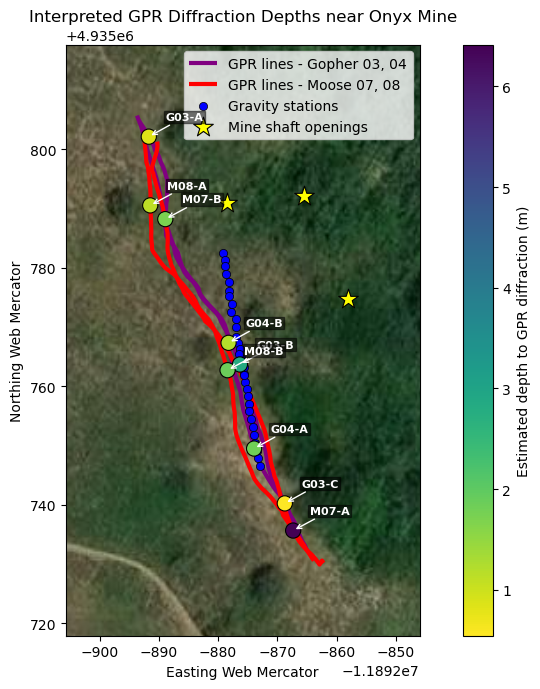

In [15]:
all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds
buffer = 12

fig, ax = plt.subplots(figsize=(9, 7))

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=220,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    markersize=120,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={"label": "Estimated depth to GPR diffraction (m)"},
    zorder=6
)

for idx, row in anomaly_3857.iterrows():

    ax.annotate(
        row["anomaly_id"],
        (row.geometry.x, row.geometry.y),      # point location
        xytext=(12, 12),                       # label offset
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        color="white",
        bbox=dict(facecolor="black", alpha=0.5, pad=1),
        arrowprops=dict(
            arrowstyle="->",
            color="white",
            lw=1
        ),
        zorder=20
    )

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()